# M2 — Watermarks: scenario testing

M2-only isolation: every verdict in this notebook is caused exclusively by
watermark evidence. Provenance, forensics, and the detector are silenced.

**Five decoders, ranked by ecosystem reach:**

| # | scheme | detects | type | verdict tier |
|---|---|---|---|---|
| 1 | dwtDct | SD 1.x/2.x/SDXL | payload match | verified |
| 2 | trustmark | Adobe Firefly | payload decode | verified |
| 3 | stable-signature-bzh | SDXL-turbo IMATAG | zero-bit (p-value) | likely |
| 4 | synthid-cnn | Google/OpenAI | learned surrogate | likely |
| 5 | meta-invisible | Meta AI | none exists | documented |

Convention: commit WITH outputs — this is a run record.

In [ ]:
# ── Setup cell 1: installs only (no imports) ──────────────────
!apt-get -qq install -y libimage-exiftool-perl > /dev/null
!git clone -q https://github.com/Waranika/AI-image-Checkers.git 2>/dev/null || echo "already cloned"
%cd /content/AI-image-Checkers
%pip install -q -e .
%pip install -q trustmark 2>/dev/null || echo "trustmark not available"
%pip install -q transformers 2>/dev/null || echo "transformers not available"

print("✓ all installs done — now restart the runtime (Runtime → Restart session)")
print("  then SKIP this cell and run the next one")

/content/AI-image-Checkers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 5.2 MB/s eta 0:00:00
  Building editable for ai-image-id (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 60.5 MB/s eta 0:00:00
   ━━━━━

In [2]:
# ── Setup — single cell, no restart ────────────────────────────
!apt-get -qq install -y libimage-exiftool-perl > /dev/null
!git clone -q https://github.com/Waranika/AI-image-Checkers.git 2>/dev/null || echo "already cloned"
%cd /content/AI-image-Checkers
%pip install -q -e . "numpy>=1.26,<2.0"   # pin <2.0 so trustmark loads without ABI mismatch
%pip install -q trustmark 2>/dev/null || echo "trustmark not available"
%pip install -q transformers 2>/dev/null || echo "transformers not available"

import numpy as np
from pathlib import Path
from PIL import Image
from ai_image_id.ingest import ingest
from ai_image_id.watermark import analyze_watermarks, dwt_dct, SDXL_BITS, SD_V1_BITS
from ai_image_id.fusion import fuse
from ai_image_id.schema import Evidence, ProvenanceEvidence, SpectrumEvidence, Verdict

def report(path, label=""):
    """M2-only evidence card. No provenance, no FFT, no detector."""
    img = ingest(path)
    wms = analyze_watermarks(img.rgb)
    evidence = Evidence(
        provenance=ProvenanceEvidence(),          # M1 silenced
        watermarks=wms,
        spectrum=SpectrumEvidence(valid=False),    # M3 silenced
        detector=None,                            # M4 silenced
    )
    r = fuse(evidence, sha256=img.sha256, phash=img.phash)
    print(f"┌─ {label or path}")
    print(f"│ verdict: {r.ai_verdict.value} ({r.confidence})")
    for w in wms:
        status = "DETECTED" if w.detected else ("n/a" if not w.applicable else "not detected")
        detail = ""
        if w.bit_accuracy is not None: detail = f" acc/p={w.bit_accuracy}"
        if w.matched_payload: detail += f" payload={w.matched_payload}"
        print(f"│   {w.scheme:<22} {status}{detail}")
        if w.notes and not w.applicable: print(f"│     └ {w.notes}")
    print(f"└ notes: {r.notes}\n")
    return r

def wm_row(path):
    """One-line summary for matrix tables."""
    img = ingest(path)
    wms = analyze_watermarks(img.rgb)
    evidence = Evidence(provenance=ProvenanceEvidence(), watermarks=wms,
                        spectrum=SpectrumEvidence(valid=False), detector=None)
    r = fuse(evidence, sha256=img.sha256, phash=img.phash)
    cols = {}
    for w in wms:
        if w.scheme in ("meta-invisible",): continue  # skip documented-only
        cols[w.scheme] = w.detected if w.applicable else None
    return cols, r.ai_verdict.value

# Decoder availability — checks imports only (no model downloads)
print("decoder availability:")
print(f"  {'dwtDct':<22} ✓ ready (vendored)")
for name, mod in [("trustmark", "trustmark"), ("stable-signature-bzh", "transformers")]:
    try:
        __import__(mod)
        print(f"  {name:<22} ✓ ready")
    except ImportError:
        print(f"  {name:<22} ✗ {mod} not installed")

/content/AI-image-Checkers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 20.3 MB/s eta 0:00:00
  Building editable for ai-image-id (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93

## 1 — DWT-DCT: synthetic round-trip (controlled ground truth)

Tests our vendored codec's self-consistency. The interesting question is
the fragility cliff: at what JPEG quality does the watermark die?

In [3]:
FIX = Path("/content/fixtures_m2"); FIX.mkdir(exist_ok=True)

rng = np.random.default_rng(7)
y, x = np.mgrid[0:512, 0:512]
base = np.clip(np.stack([120+60*np.sin(x/97), 100+50*np.cos(y/83),
                         90+40*np.sin((x+y)/71)], -1) + rng.normal(0,6,(512,512,3)),
               0, 255).astype(np.uint8)

# Embed SDXL payload, save at various qualities
marked = dwt_dct.embed(base, SDXL_BITS)
for q_label, save_fn in [
    ("lossless", lambda p: Image.fromarray(marked).save(p)),
    ("q92",      lambda p: Image.fromarray(marked).save(p, quality=92)),
    ("q80",      lambda p: Image.fromarray(marked).save(p, quality=80)),
    ("q70",      lambda p: Image.fromarray(marked).save(p, quality=70)),
]:
    p = FIX/f"sdxl_{q_label}.{'png' if q_label=='lossless' else 'jpg'}"
    save_fn(p)
    report(str(p), f"SDXL payload, {q_label}")

# Clean baseline
p = FIX/"clean.png"; Image.fromarray(base).save(p)
report(str(p), "no watermark (baseline)")

Fetching model file (once only): /usr/local/lib/python3.12/dist-packages/trustmark/models/trustmark_rm_Q.ckpt


preprocessor_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/736 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 44.8MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/122 [00:00<?, ?it/s]

synthid-cnn: downloading resnet18 weights (https://raw.githubusercontent.com/newideas99/gpt-image-synthid-detector/main/weights/surrogate_resnet18.pt)...
synthid-cnn: downloading resnet34 weights (https://raw.githubusercontent.com/newideas99/gpt-image-synthid-detector/main/weights/surrogate_resnet34.pt)...
synthid-cnn: downloading efficientnet_b0 weights (https://raw.githubusercontent.com/newideas99/gpt-image-synthid-detector/main/weights/surrogate_efficientnet_b0.pt)...
┌─ SDXL payload, lossless
│ verdict: verified (0.95)
│   dwtDct                 DETECTED acc/p=0.917 payload=sdxl-48bit
│   trustmark              not detected
│   stable-signature-bzh   not detected acc/p=0.0
│   synthid-cnn            not detected acc/p=0.2285
│   meta-invisible         n/a
│     └ no public decoder; Meta's proprietary scheme
└ notes: ["SD invisible watermark matched 'sdxl-48bit' (bit accuracy 0.917)"]

┌─ SDXL payload, q92
│ verdict: inconclusive (0.5)
│   dwtDct                 not detected acc/p=0

AnalysisResult(ai_verdict=<Verdict.INCONCLUSIVE: 'inconclusive'>, confidence=0.5, evidence=Evidence(provenance=ProvenanceEvidence(c2pa_present=False, c2pa_valid=None, c2pa_signature_valid=None, c2pa_signer_trusted=None, c2pa_generator=None, c2pa_capture_claim=False, c2pa_actions=[], c2pa_raw=None, generation_params_tool=None, generation_params_model=None, iptc_digital_source_type=None, iptc_source_category=None, software=None, camera_exif_present=False, camera_exif_fields=0, ai_metadata_hits=[]), watermarks=[WatermarkEvidence(scheme='dwtDct', applicable=True, detected=False, matched_payload=None, bit_accuracy=0.542, notes=None), WatermarkEvidence(scheme='trustmark', applicable=True, detected=False, matched_payload=None, bit_accuracy=None, notes=None), WatermarkEvidence(scheme='stable-signature-bzh', applicable=True, detected=False, matched_payload=None, bit_accuracy=0.0, notes='not detected, p(watermarked)=0.0'), WatermarkEvidence(scheme='synthid-cnn', applicable=True, detected=False, 

In [4]:
# Which decoder is actually running?
try:
    from imwatermark import WatermarkDecoder
    print("using: imwatermark (real package)")
except ImportError:
    print("using: vendored dwt_dct")

using: vendored dwt_dct


Test because fails

In [6]:
# ── TrustMark round-trip: encode a watermark, then decode it ───────────
# Proves the codec works end-to-end, independent of any generator.
# If this fails, the decoder is broken. If it passes, then "not detected"
# on real images means those images genuinely don't carry TrustMark.
from google.colab import files
from trustmark import TrustMark
from PIL import Image
import inspect

# Show the real API so we use the right arguments
print("TrustMark.encode signature:", inspect.signature(TrustMark.encode))
print("TrustMark.decode signature:", inspect.signature(TrustMark.decode), "\n")

tm = TrustMark(verbose=False, model_type='Q')

print("Upload any image to watermark (a clean photo is fine):")
up = files.upload()
src = next(iter(up))
img = Image.open(src).convert("RGB")

# Encode a test payload. TrustMark's default schema (BCH_5) carries a short
# ASCII string; adjust if the signature above shows a different arg shape.
PAYLOAD = "TESTMARK01"
encoded = tm.encode(img, PAYLOAD)
# encode may return a PIL image directly or a tuple — handle both
enc_img = encoded[0] if isinstance(encoded, tuple) else encoded
enc_img.save("/content/tm_encoded.png")

# Decode from the in-memory image
result = tm.decode(enc_img)
print(f"\nin-memory round-trip: {result}")

# Decode from the saved-and-reloaded file (tests PNG survival)
reloaded = Image.open("/content/tm_encoded.png").convert("RGB")
result2 = tm.decode(reloaded)
print(f"after save+reload:    {result2}")

TrustMark.encode signature: (self, in_cover_image, string_secret, MODE='text', WM_STRENGTH=1.0, WM_MERGE='bilinear')
TrustMark.decode signature: (self, in_stego_image, MODE='text', DETECTFIRST=False, ROTATION=False) 

Upload any image to watermark (a clean photo is fine):


Saving 3680a92321dfb4eadc1bd645bb916088.jpg to 3680a92321dfb4eadc1bd645bb916088.jpg

in-memory round-trip: ('TESTMARK0', True, 1)
after save+reload:    ('TESTMARK0', True, 1)


In [7]:
# ── TrustMark on real images: does any generator actually embed it? ────
# Upload Firefly exports, Adobe Content Authenticity app outputs, or any
# image you want to check. Firefly's raw web export likely won't carry it
# (TrustMark is applied via the Content Authenticity app, not by default) —
# to get a positive, run your Firefly image through contentauthenticity.adobe.com
# first, then upload THAT output here.
from google.colab import files
from trustmark import TrustMark
from PIL import Image

tm = TrustMark(verbose=False, model_type='Q')

print("Upload real images to check for TrustMark (Firefly, CA-app outputs, etc.):")
up = files.upload()
for name in sorted(up):
    img = Image.open(name).convert("RGB")
    result = tm.decode(img)
    # decode returns (secret, present, schema) or similar — print raw so we
    # see the true shape, then interpret
    print(f"\n{name}")
    print(f"  raw decode result: {result}")
    if isinstance(result, (tuple, list)) and len(result) >= 2:
        secret, present = result[0], result[1]
        print(f"  → {'DETECTED' if present else 'not detected'}"
              + (f" | payload: {secret}" if present else ""))

Upload real images to check for TrustMark (Firefly, CA-app outputs, etc.):


Saving Firefly_A really cool dog 126032.png to Firefly_A really cool dog 126032.png

Firefly_A really cool dog 126032.png
  raw decode result: ('', False, -1)
  → not detected


## 2 — DWT-DCT fragility curve

Sweep JPEG quality 50–98: bit accuracy vs. compression. The cliff location
tells us where M2's DWT-DCT decoder stops being useful in practice.

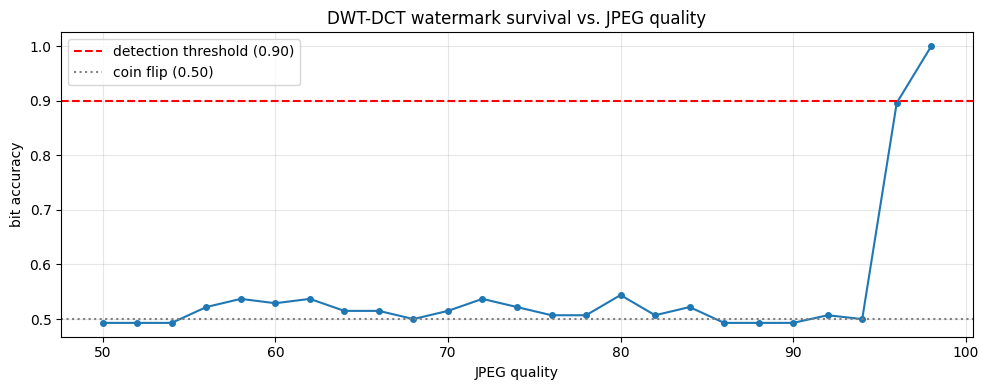

DWT-DCT detectable (≥0.90) above Q=98


In [ ]:
import matplotlib.pyplot as plt

qualities = list(range(50, 100, 2))
accuracies = []
for q in qualities:
    p = FIX/f"sweep_q{q}.jpg"
    Image.fromarray(marked).save(p, quality=q)
    img = ingest(p)
    wms = analyze_watermarks(img.rgb)
    best = next((w for w in wms if w.scheme == "dwtDct" and w.bit_accuracy is not None), None)
    accuracies.append(best.bit_accuracy if best else 0.5)

plt.figure(figsize=(10, 4))
plt.plot(qualities, accuracies, "o-", markersize=4)
plt.axhline(0.90, color="red", linestyle="--", label="detection threshold (0.90)")
plt.axhline(0.50, color="gray", linestyle=":", label="coin flip (0.50)")
plt.xlabel("JPEG quality"); plt.ylabel("bit accuracy")
plt.title("DWT-DCT watermark survival vs. JPEG quality")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("/content/m2_dwtdct_curve.png", dpi=150); plt.show()

cliff = next((q for q, a in zip(qualities, accuracies) if a and a >= 0.90), None)
print(f"DWT-DCT detectable (≥0.90) above Q={cliff}" if cliff else "never reaches threshold")

## 3 — Real images: the validation gauntlet

Upload real images from different generators. Expected behavior per decoder:

| image source | dwtDct | trustmark | stable-sig | synthid-cnn |
|---|---|---|---|---|
| Real SDXL (diffusers + invisible-watermark) | ✓ detect | · | · | · |
| Adobe Firefly export | · | ✓ detect | · | · |
| OpenAI/ChatGPT PNG | · | · | · | ✓ detect |
| Google Gemini image | · | · | · | ✓ detect |
| Phone photo | · | · | · | · |
| Screenshot of any AI image | · | · | · | maybe ✓ |

The last row is the key test: SynthID CNN claims transport survival.
Upload your OpenAI PNG AND its screenshot to compare.

In [ ]:
from google.colab import files
up = files.upload()
for name in sorted(up):
    report(name)


print("Stable from YeriAI")

Saving YERIAI.png to YERIAI.png
┌─ YERIAI.png
│ verdict: likely (0.88)
│   dwtDct                 not detected acc/p=0.562
│   trustmark              not detected
│   stable-signature-bzh   not detected acc/p=0.0
│   synthid-cnn            DETECTED acc/p=0.7046
│   meta-invisible         n/a
│     └ no public decoder; Meta's proprietary scheme
└ notes: ['SynthID watermark detected by learned surrogate (ensemble P(wm)=0.7046)']

Stable from YeriAI


In [ ]:
from google.colab import files
up = files.upload()
for name in sorted(up):
    report(name)


print("OpenAI")

Saving ChatGPT Image Jul 6, 2026, 11_56_43 PM.png to ChatGPT Image Jul 6, 2026, 11_56_43 PM (1).png
┌─ ChatGPT Image Jul 6, 2026, 11_56_43 PM (1).png
│ verdict: likely (0.88)
│   dwtDct                 not detected acc/p=0.5
│   trustmark              not detected
│   stable-signature-bzh   not detected acc/p=0.0
│   synthid-cnn            DETECTED acc/p=0.9917
│   meta-invisible         n/a
│     └ no public decoder; Meta's proprietary scheme
└ notes: ['SynthID watermark detected by learned surrogate (ensemble P(wm)=0.9917)']

OpenAI


In [ ]:
from google.colab import files
up = files.upload()
for name in sorted(up):
    report(name)


print("OpenAI's screenshot")

Saving Screenshot 2026-07-06 at 23.58.56.png to Screenshot 2026-07-06 at 23.58.56.png
┌─ Screenshot 2026-07-06 at 23.58.56.png
│ verdict: likely (0.88)
│   dwtDct                 not detected acc/p=0.5
│   trustmark              not detected
│   stable-signature-bzh   not detected acc/p=0.0
│   synthid-cnn            DETECTED acc/p=0.9935
│   meta-invisible         n/a
│     └ no public decoder; Meta's proprietary scheme
└ notes: ['SynthID watermark detected by learned surrogate (ensemble P(wm)=0.9935)']

OpenAI's screenshot


In [ ]:
from google.colab import files
up = files.upload()
for name in sorted(up):
    report(name)


print("FireFly")

Saving Firefly_A really cool dog 126032.png to Firefly_A really cool dog 126032.png
┌─ Firefly_A really cool dog 126032.png
│ verdict: likely (0.88)
│   dwtDct                 not detected acc/p=0.5
│   trustmark              not detected
│   stable-signature-bzh   not detected acc/p=0.0
│   synthid-cnn            DETECTED acc/p=0.9946
│   meta-invisible         n/a
│     └ no public decoder; Meta's proprietary scheme
└ notes: ['SynthID watermark detected by learned surrogate (ensemble P(wm)=0.9946)']

FireFly


In [ ]:
from google.colab import files
up = files.upload()
for name in sorted(up):
    report(name)


print("Witness test")

Saving IMG_9415.jpeg to IMG_9415.jpeg
┌─ IMG_9415.jpeg
│ verdict: likely (0.88)
│   dwtDct                 not detected acc/p=0.5
│   trustmark              not detected
│   stable-signature-bzh   not detected acc/p=0.0
│   synthid-cnn            DETECTED acc/p=0.6528
│   meta-invisible         n/a
│     └ no public decoder; Meta's proprietary scheme
└ notes: ['SynthID watermark detected by learned surrogate (ensemble P(wm)=0.6528)']

Witness test


## 4 — Transport-degradation matrix (M2 signals)

Same seven hops as notebook 03 (M1). The hypothesis: watermarks survive
transforms that kill metadata. Compare column-by-column with the M1 matrix.

Upload a watermarked image when prompted (your OpenAI PNG is the best
candidate — it carries both C2PA for M1 comparison and SynthID for M2).

In [ ]:
import shutil, subprocess

up = files.upload()
orig = Path(next(iter(up)))
HOP = Path("/content/hops_m2"); HOP.mkdir(exist_ok=True)
im = Image.open(orig).convert("RGB")

hops = {"0-original": orig}
p = HOP/"1-resave.jpg";     im.save(p, quality=92);  hops["1-resave-jpg"] = p
p = HOP/"2-screenshot.png"; im.save(p);               hops["2-screenshot"] = p
p = HOP/"3-messenger.jpg";  im.resize((im.width//2, im.height//2)).save(p, quality=70)
hops["3-messenger"] = p
p = HOP/("4-strip"+orig.suffix); shutil.copy(orig, p)
subprocess.run(["exiftool","-overwrite_original","-all=",str(p)], capture_output=True)
hops["4-exiftool-strip"] = p
p = HOP/"5-crop.jpg"; im.crop((50,50,im.width-50,im.height-50)).save(p, quality=92)
hops["5-crop"] = p
p = HOP/"6-pil-reencode.png"; im.save(p)
hops["6-pil-reencode"] = p

SCHEMES = ["dwtDct", "trustmark", "stable-signature-bzh", "synthid-cnn"]
header = f"{'transport':<20}" + "".join(f"{s:<22}" for s in SCHEMES) + "verdict"
print(header)
for name, path in hops.items():
    cols, verdict = wm_row(path)
    row = f"{name:<20}"
    for s in SCHEMES:
        v = cols.get(s)
        row += f"{'✓' if v else ('·' if v is False else '—'):<22}"
    row += verdict
    print(row)

NameError: name 'files' is not defined

### Reading the matrix — M1 vs M2 comparison

Place this side-by-side with notebook 03's M1 matrix:

**M1 (provenance):** C2PA survives only exiftool-strip; everything else dies.

**M2 (watermarks) — expected pattern:**
- *dwtDct:* fragile — dies at any JPEG recompression below its cliff Q
- *trustmark:* designed for transport survival — should survive re-save, crop,
  possibly messenger. THE complementary signal to C2PA.
- *synthid-cnn:* trained against JPEG/blur/crop/screenshot — should survive
  most hops. If it does, it's the most durable signal in the entire pipeline.

The composite picture: M1 proves origin on pristine images; M2 extends
detection through reprocessing; together they cover more scenarios than
either alone. That complementarity is the evidence-fusion thesis.

## 5 — Cross-decoder agreement test

Run all decoders on the SAME image. When multiple decoders fire on the same
file, it's strong corroboration. When they disagree, it's interesting
(e.g., SynthID CNN fires but TrustMark doesn't → image is Google/OpenAI,
not Adobe). Decoder agreement patterns are implicit generator attribution.

In [ ]:
# Re-run on all uploaded images from §3, showing per-decoder verdicts side by side
import os
uploads = [f for f in os.listdir("/content") if f.endswith((".png",".jpg",".jpeg",".webp"))
           and "fixture" not in f and "sweep" not in f and "hop" not in f]
if not uploads:
    print("no uploaded images found — run §3 first")
else:
    print(f"{'image':<40}" + "".join(f"{s:<18}" for s in SCHEMES))
    for name in sorted(uploads):
        cols, verdict = wm_row(f"/content/{name}")
        row = f"{name[:38]:<40}"
        for s in SCHEMES:
            v = cols.get(s)
            row += f"{'✓' if v else ('·' if v is False else '—'):<18}"
        print(f"{row}  → {verdict}")

no uploaded images found — run §3 first


## 6 — Scope: what M2 covers and doesn't

| generator | watermark scheme | M2 decoder | status |
|---|---|---|---|
| SD 1.x/2.x/SDXL (with invisible-watermark) | DWT-DCT | `_check_dwtdct` | implemented |
| Adobe Firefly | TrustMark | `_check_trustmark` | implemented |
| SDXL-turbo IMATAG builds | Stable Signature BZH | `_check_stable_signature_bzh` | implemented |
| Google Gemini / Imagen | SynthID | `_check_synthid_cnn` (surrogate) | implemented (learned, not cryptographic) |
| OpenAI GPT-Image-2 | SynthID | `_check_synthid_cnn` (surrogate) | implemented (learned, not cryptographic) |
| Meta AI | proprietary | none | **blocked** — no public decoder |
| Midjourney | none known | — | no watermark to detect |
| Flux, Leonardo, Ideogram, Recraft | none known | — | no watermark to detect |

Honest boundary: decoders 1–2 verify payloads (cryptographic confidence);
3–4 detect statistical presence (learned confidence, ~3% FP possible).
For generators with no watermark, only M1 (metadata) and M4 (classifier)
provide signal.